### Logistic regression — formulas, derived

**Sigmoid**
sigmoid(z) = 1 / (1 + e^-z)
Squashes any real z into (0,1). At z=0: e^0=1 -> 1/(1+1)=0.5. As z->+inf: e^-z->0 -> output->1. As z->-inf: e^-z->inf -> output->0.
Derivative: sigmoid'(z) = sigmoid(z)*(1-sigmoid(z)) = p(1-p) -- steepest at p=0.5, flat at the extremes.

**Log-loss, derived from maximum likelihood**
Treat each label as a coin flip: P(y=1)=p, P(y=0)=1-p, written as one expression: P(y|p) = p^y * (1-p)^(1-y)
Likelihood of the whole dataset = product of this over all points. Take log (turns product into sum), negate (turns maximize into minimize, the loss convention):
L = -[y*log(p) + (1-y)*log(1-p)]

**Gradient, via chain rule: dL/dw = dL/dp * dp/dz * dz/dw**
- dL/dp = (p-y) / [p(1-p)]     (differentiate L above)
- dp/dz = p(1-p)                (sigmoid's own derivative)
- dz/dw = x                      (z = w.x + b)

Multiply the first two -- the p(1-p) terms cancel exactly:
dL/dw = (p-y) * x


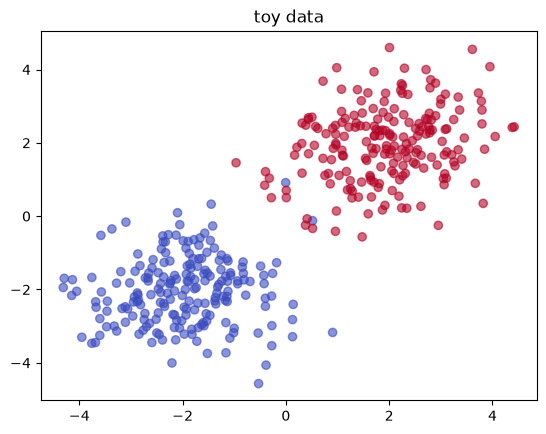

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

n = 200
X0 = rng.normal(loc=[-2, -2], scale=1.0, size=(n, 2))
X1 = rng.normal(loc=[2, 2], scale=1.0, size=(n, 2))
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("toy data")
plt.show()

# squashes any real z into (0,1); derivative = p(1-p) -> steep at 0.5, flat at extremes
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# negative log-likelihood of a Bernoulli label (from MLE) -- punishes confident-and-wrong hard
def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)  # guards log() against log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


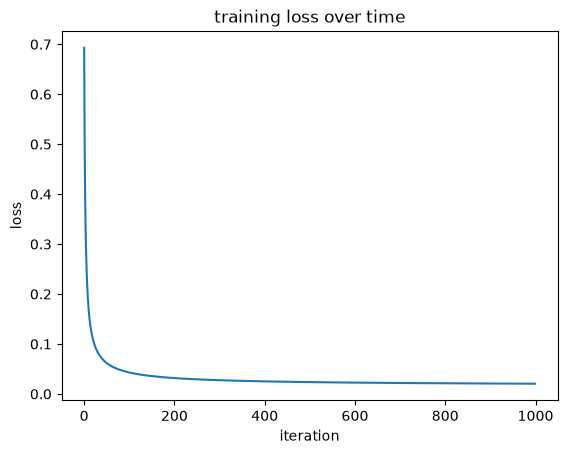

learned w: [1.93572205 1.9769888 ]
learned b: 0.3230796840918288


In [2]:
def train_logistic_regression(X, y, lr=0.1, n_iters=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)   # start with no opinion — all weights zero
    b = 0.0
    losses = []

    for i in range(n_iters):
        z = X @ w + b               # the linear part: w·x + b, for every row at once
        p = sigmoid(z)               # squash into probabilities

        loss = log_loss(y, p)
        losses.append(loss)

        # (p-y)*x is the derived per-point gradient; dividing by n_samples averages
        # instead of sums, so the update size doesn't depend on how many rows we have
        dw = (X.T @ (p - y)) / n_samples
        db = np.mean(p - y)          # same gradient, but for the bias (x is implicitly 1 here)

        w -= lr * dw                 # step opposite the gradient — that's what makes loss go down
        b -= lr * db

    return w, b, losses

w, b, losses = train_logistic_regression(X, y, lr=0.1, n_iters=1000)

plt.plot(losses)
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("training loss over time")
plt.show()

print("learned w:", w)
print("learned b:", b)


In [ ]:
from sklearn.linear_model import LogisticRegression

sklearn_model = LogisticRegression()
sklearn_model.fit(X, y)

print("sklearn w:", sklearn_model.coef_[0])
print("sklearn b:", sklearn_model.intercept_[0])

# ours:    w=[1.936, 1.977], b=0.323
# sklearn: w=[1.884, 1.887], b=0.489
# same sign, same rough ratio between the two features -> confirms our from-scratch
# gradient derivation is correct. Not identical because sklearn adds L2 regularization
# by default and uses a different optimizer, not plain gradient descent.


### Likely interview questions

**Q: Why sigmoid, not some other squashing function?**
It's the inverse of the logit — the natural link between "linear in log-odds" and "output as a probability." It also pairs with log-loss for a clean single-term gradient, (p-y)x; a different squashing function wouldn't cancel that cleanly.

**Q: Why log-loss instead of MSE?**
Log-loss falls directly out of maximum likelihood for a Bernoulli label, not chosen by convention. Practically: MSE with a sigmoid output is non-convex (gradient descent can get stuck); log-loss with sigmoid is convex, one global minimum guaranteed.

**Q: How do you interpret a logistic regression coefficient?**
Change in log-odds of the positive class per unit increase in that feature, holding others fixed. Exponentiate it (e^w) for an odds ratio — e.g. e^w=1.5 means a 50% increase in the odds of fraud per unit.

**Q: Why can't logistic regression capture "high amount AND risky category" the way a rule can?**
z is a plain sum of independently-weighted features — no term for two features acting together unless you engineer one explicitly (e.g. amt × category). Saw this directly: a hand-written AND rule beat logistic regression at equal recall on the fraud project.

**Q: Why does logistic regression need feature scaling but trees don't?**
Coefficients are tied to feature magnitude — an unscaled large-range feature dominates the loss from scale alone. Trees split on "is this value above X," which is scale-invariant.

**Q: How do you handle severe class imbalance?**
Weight each sample's loss inversely to its class frequency (class_weight="balanced"), or resample. And don't trust a default 0.5 threshold — pick the operating threshold from the actual cost of each error type.

**Q: Is logistic regression linear?**
Yes where it matters — the decision boundary (p=0.5) is a linear hyperplane, and it's linear in log-odds. Sigmoid itself is nonlinear, but that's just the link function, not the model's structure.

**Q: L1 vs L2 regularization?**
Both shrink coefficients toward zero. L1 (Lasso) can push some exactly to zero — automatic feature selection. L2 (Ridge, sklearn's default) shrinks smoothly, rarely to exactly zero — better when many features contribute a little rather than a few mattering a lot.
